# Direct GPQR

In [ ]:
import os

import torch
from torch.distributions import Normal
from gpytorch.variational import CholeskyVariationalDistribution
from gpytorch.variational import VariationalStrategy, LMCVariationalStrategy
from gpytorch.means import ConstantMean
from gpytorch.kernels import RBFKernel, ScaleKernel
from gpytorch.mlls import VariationalELBO
import matplotlib.pyplot as plt

from gpytorch_qr.models import DirectQuantileGP
from gpytorch_qr.likelihoods import DirectQuantileLikelihood

try:
    import sys

    sys.path.insert(0, os.path.abspath(".."))

    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# n_epochs = int(os.getenv("GPYTORCHQR_N_EPOCHS", 5000))
n_epochs = 1

## Data preparation

In [ ]:
def mean1(x):
    return torch.cos(x * 2 * 3.14)


def mean2(x):
    return torch.sin(x * 2 * 3.14)


def std(x):
    return x + 0.1


x_range = torch.linspace(0, 1, 100).reshape(-1, 1).to(device)
x = x_range.repeat(5, 1)
y1 = mean1(x) + torch.randn(x.shape, device=device).mul(std(x))
y2 = mean2(x) + torch.randn(x.shape, device=device).mul(std(x))
y = torch.concatenate([y1, y2], dim=-1)

q1 = torch.tensor([0.1, 0.5, 0.9], device=device)
true_quantiles1 = mean1(x_range) + Normal(0, std(x_range)).icdf(q1)

q2 = torch.tensor([0.1, 0.25, 0.5, 0.75, 0.9], device=device)
true_quantiles2 = mean2(x_range) + Normal(0, std(x_range)).icdf(q2)

x_pred = torch.linspace(0, 1.5, 100).reshape(-1, 1).to(device)

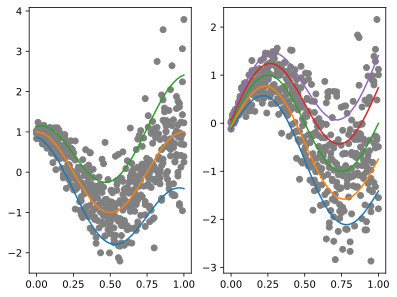

In [ ]:
fig, axes = plt.subplots(1, 2)

axes[0].scatter(x.cpu(), y1.cpu(), c="gray")
axes[0].plot(x_range.cpu(), true_quantiles1.cpu())

axes[1].scatter(x.cpu(), y2.cpu(), c="gray")
axes[1].plot(x_range.cpu(), true_quantiles2.cpu())

fig.show()

## Define model and likelihood

In [ ]:
class MyGP(DirectQuantileGP):
    def __init__(self, inducing_points, num_quantiles, num_latents):
        N, D = inducing_points.size()
        variational_distribution = CholeskyVariationalDistribution(
            N,
            batch_shape=torch.Size([num_latents]),
        )
        variational_strategy = LMCVariationalStrategy(
            VariationalStrategy(
                self,
                inducing_points,
                variational_distribution,
                learn_inducing_locations=True,
            ),
            num_tasks=num_quantiles,
            num_latents=num_latents,
        )

        mean_module = ConstantMean(batch_shape=torch.Size([num_latents]))
        covar_module = ScaleKernel(
            RBFKernel(ard_num_dims=D, batch_shape=torch.Size([num_latents])),
            batch_shape=torch.Size([num_latents]),
        )
        super().__init__(variational_strategy, mean_module, covar_module)


inducing_points = torch.linspace(0, 1, 10).reshape(-1, 1).to(device)
num_latents = len(q1) + len(q2) - 2
gp = MyGP(inducing_points, len(q1) + len(q2), num_latents=num_latents).to(device)
likelihood = DirectQuantileLikelihood(torch.concat([q1, q2])).to(device)

## Train

In [ ]:
gp.train()
likelihood.train()
mll = VariationalELBO(likelihood, gp, num_data=len(y))
optimizer = torch.optim.Adam(
    list(gp.parameters()) + list(likelihood.parameters()),
    lr=0.001,
)

In [ ]:
# output = gp(x)
# output

In [ ]:
# output.batch_shape, output.event_shape

In [ ]:
# likelihood_samples = likelihood._draw_likelihood_samples(output)
# likelihood_samples

In [ ]:
# likelihood_samples.log_prob(y).mean(dim=0)

In [ ]:
# mll(output, y)

MultitaskMultivariateNormal은 한개의 task 차원만을 허용하므로 y1과 y2의 quantiles는 flatten될 수밖에 없음.

DirectQuantileLikelihood가 list of quantiles를 받아서 task dimension별로 적용하게끔 해야 함.